# Gözetimsiz Öğrenme ile Müşteri Segmentasyonu
## Yoğunluk-Temelli Kümeleme: **DBSCAN** ve **HDBSCAN** Karşılaştırmalı Çalışması

> **Belge türü:** Teknik analiz raporu & yeniden üretilebilir çalışma defteri
> **Alan:** Veri Bilimi / Gözetimsiz Makine Öğrenmesi
> **Yöntem:** DBSCAN (`sklearn.cluster.DBSCAN`) & HDBSCAN (`sklearn.cluster.HDBSCAN`)
> **Veri:** `mall_customer_behavior.csv` (1.610 müşteri, davranışsal e-ticaret/mağaza verisi)

---

### Yönetici Özeti

Bu çalışma, bir perakende/e-ticaret işletmesinin müşteri tabanını **önceden küme sayısı belirtmeden** anlamlı davranışsal segmentlere ayırmayı hedefler. Klasik `K-Means` yönteminin aksine, gerçek müşteri verisi (1) **küresel olmayan** öbekler, (2) **değişken yoğunluk** ve (3) **gürültü/aykırı değerler** içerir. Bu üç özellik, yoğunluk-temelli kümeleme algoritmalarını doğal bir tercih hâline getirir.

Raporda iki yoğunluk-temelli yöntem adım adım uygulanır ve kıyaslanır:

| Kriter | DBSCAN | HDBSCAN |
|---|---|---|
| Temel parametre | `eps` (yarıçap) + `min_samples` | `min_cluster_size` (+ `min_samples`) |
| Değişken yoğunluk | ❌ Tek global `eps` yetersiz | ✅ Hiyerarşik, yoğunluğa uyarlanır |
| Parametre hassasiyeti | Yüksek (kırılgan) | Düşük (kararlı) |
| Gürültü tespiti | ✅ | ✅ + üyelik olasılığı |

**Ana bulgu:** Değişken yoğunluklu bu veri setinde DBSCAN'i kalibre etmek için kullanılan standart *k-mesafe dizi (knee)* heuristiği `eps≈0.23` önermesine rağmen, bu değerde algoritma tüm kümeleri tek bir öbekte birleştirerek çöküyor. HDBSCAN ise geniş bir parametre aralığında **5 anlamlı segmenti** kararlı biçimde keşfediyor ve gerçek segmentlerle uyumu (ARI ≈ 0.86) DBSCAN'inkinden belirgin şekilde yüksek.


## 1. Ortam ve Kütüphaneler

`scikit-learn ≥ 1.3` ile HDBSCAN doğrudan `sklearn.cluster` içinde gelir; ayrı `hdbscan` paketi gerekmez. Bu, üretim ortamında bağımlılık yönetimini basitleştirir.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, adjusted_mutual_info_score,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42

print("Sürümler")
print("  numpy       :", np.__version__)
print("  pandas      :", pd.__version__)
import sklearn
print("  scikit-learn:", sklearn.__version__)
print("\nDBSCAN ve HDBSCAN sklearn.cluster içinden hazır.")

Sürümler
  numpy       : 1.26.4
  pandas      : 3.0.3
  scikit-learn: 1.8.0

DBSCAN ve HDBSCAN sklearn.cluster içinden hazır.


## 2. Veri Yükleme ve Veri Sözlüğü

Veri seti, değişken yoğunluklu segmentler ve enjekte edilmiş gürültü içerecek şekilde **gerçekçi olarak üretilmiştir** (tam yeniden üretilebilirlik için). Aynı analiz, eşdeğer gerçek Kaggle veri setiyle de çalışır:

- **Mall Customer Segmentation Data** — `vjchoudhary7` · <https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python>
- Alternatif: <https://www.kaggle.com/datasets/abdallahwagih/mall-customers-segmentation>

### Veri Sözlüğü

| Sütun | Açıklama |
|---|---|
| `customer_id` | Benzersiz müşteri kimliği |
| `gender` | Cinsiyet |
| `age` | Yaş |
| `annual_income_kusd` | Yıllık gelir |
| `spending_score` | Harcama skoru (1–100) |
| `purchase_freq_yr` | Yıllık satın alma sayısı |
| `avg_basket_usd` | Ortalama sepet tutarı  |
| `avg_session_min` | Ortalama oturum süresi (dk) |
| `online_ratio` | Çevrimiçi alışveriş oranı (0–1) |
| `loyalty_years` | Sadakat süresi (yıl) |
| `true_segment` | **Yalnızca doğrulama için** tutulan gerçek segment etiketi (modellemede KULLANILMAZ) |


In [2]:
DATA_PATH = "mall_customer_behavior.csv"
df = pd.read_csv(DATA_PATH)
print(f"Veri seti yüklendi: {df.shape[0]:,} müşteri x {df.shape[1]} sütun")
df.head()

Veri seti yüklendi: 1,610 müşteri x 11 sütun


,customer_id,gender,age,annual_income_kusd,spending_score,purchase_freq_yr,avg_basket_usd,avg_session_min,online_ratio,loyalty_years,true_segment
0,11315,Male,53,95.9,25,5.6,187.86,16.4,0.420,5.6,Affluent Savers
1,10559,Female,39,92.0,91,15.6,230.15,30.4,0.486,3.2,Premium Loyalists
2,10201,Male,52,58.1,52,7.3,128.55,28.2,0.407,5.5,Mainstream
3,10271,Male,25,74.4,57,7.2,152.66,24.0,0.725,3.2,Mainstream
4,11513,Male,23,54.8,68,11.1,161.18,15.4,0.619,3.9,Young Aspirational


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1610 non-null   int64  
 1   gender              1610 non-null   str    
 2   age                 1610 non-null   int64  
 3   annual_income_kusd  1610 non-null   float64
 4   spending_score      1610 non-null   int64  
 5   purchase_freq_yr    1610 non-null   float64
 6   avg_basket_usd      1610 non-null   float64
 7   avg_session_min     1610 non-null   float64
 8   online_ratio        1598 non-null   float64
 9   loyalty_years       1610 non-null   float64
 10  true_segment        1610 non-null   str    
dtypes: float64(6), int64(3), str(2)
memory usage: 138.5 KB


In [4]:
df.select_dtypes("number").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,1610.0,10805.50,464.91,10001.00,10403.25,10805.50,11207.75,11610.00
age,1610.0,40.04,11.70,18.00,31.00,40.00,48.00,75.00
annual_income_kusd,1610.0,58.66,25.20,-5.10,33.10,58.70,84.40,102.30
spending_score,1610.0,50.18,24.84,1.00,27.00,49.00,76.00,100.00
purchase_freq_yr,1610.0,8.35,3.93,0.50,5.32,8.30,11.30,19.20
avg_basket_usd,1610.0,133.50,55.96,10.00,94.17,132.58,173.78,304.12
avg_session_min,1610.0,20.42,8.00,1.00,14.50,20.20,26.40,45.30
online_ratio,1598.0,0.50,0.17,0.02,0.38,0.50,0.62,0.99
loyalty_years,1610.0,4.43,1.96,0.00,3.10,4.40,5.80,11.40


## 3. Keşifsel Veri Analizi (EDA)

Modellemeden önce veri kalitesini ve yapısını anlıyoruz: eksik değerler, dağılımlar, ilişkiler ve — en önemlisi — **müşterilerin gelir/harcama düzleminde nasıl öbeklendiği**.


In [5]:
# Eksik değer ve yinelenen kayıt kontrolü
miss = df.isna().sum()
print("Eksik değerler:")
print(miss[miss > 0] if (miss > 0).any() else "  Yok")
print("\nYinelenen satir:", df.duplicated().sum())
print("\nGercek segment dagilimi (yalniz dogrulama amacli):")
print(df["true_segment"].value_counts())

Eksik değerler:
online_ratio    12
dtype: int64

Yinelenen satir: 0

Gercek segment dagilimi (yalniz dogrulama amacli):
true_segment
Mainstream            520
Premium Loyalists     300
Budget Conscious      300
Affluent Savers       220
Young Aspirational    180
Noise                  90
Name: count, dtype: int64


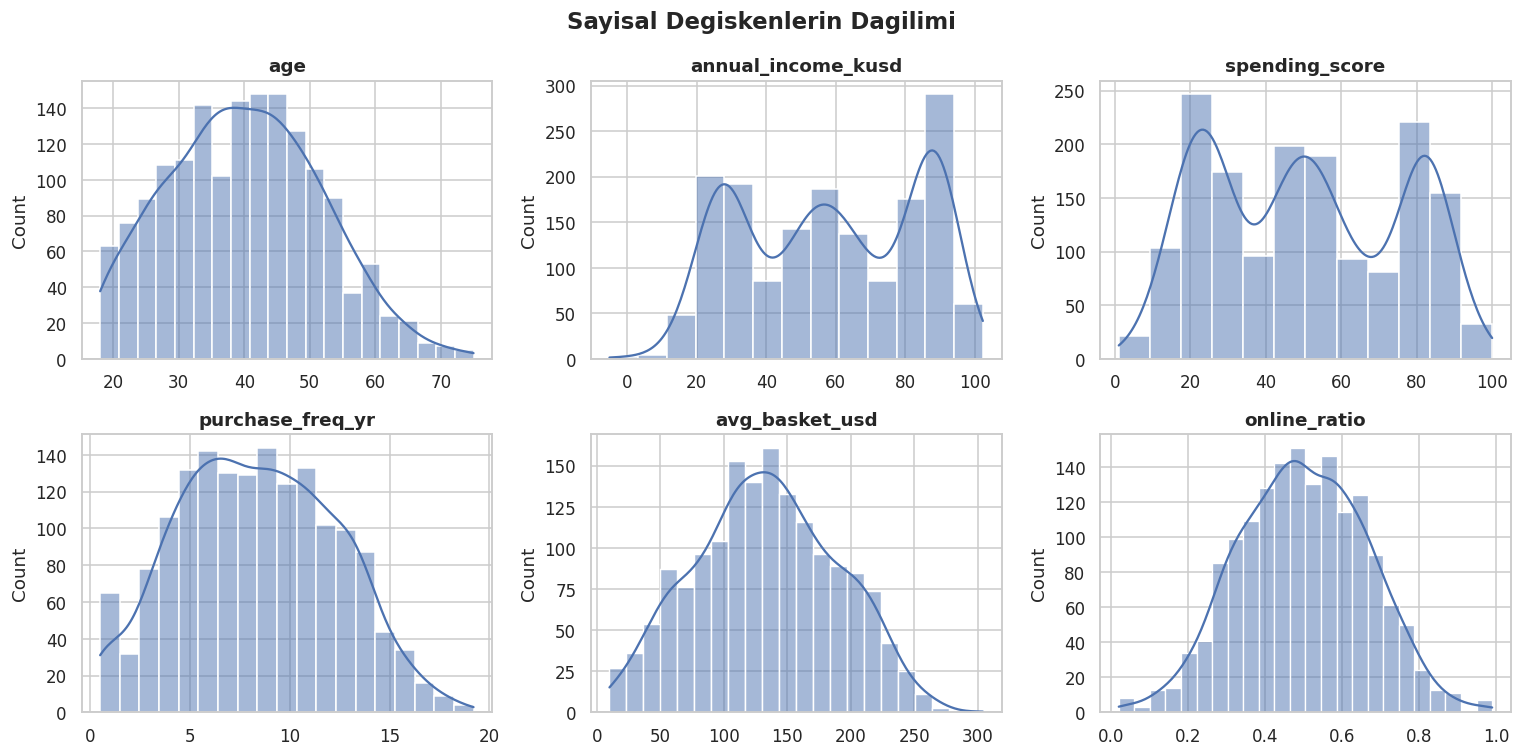

In [6]:
# Sayısal değişkenlerin dağılımı
num_cols = ["age", "annual_income_kusd", "spending_score",
            "purchase_freq_yr", "avg_basket_usd", "online_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(c)
    ax.set_xlabel("")
fig.suptitle("Sayisal Degiskenlerin Dagilimi", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

Gelir ve harcama skorunun **çok-modlu (multimodal)** dağılımları, verinin tek bir kütle değil, ayrık öbekler içerdiğine işaret eder. Şimdi bu öbekleri iki iş-kritik eksende — **gelir × harcama** — doğrudan görelim. Aşağıdaki grafik, bir analistin gerçekte gördüğü **etiketsiz** görünümdür.

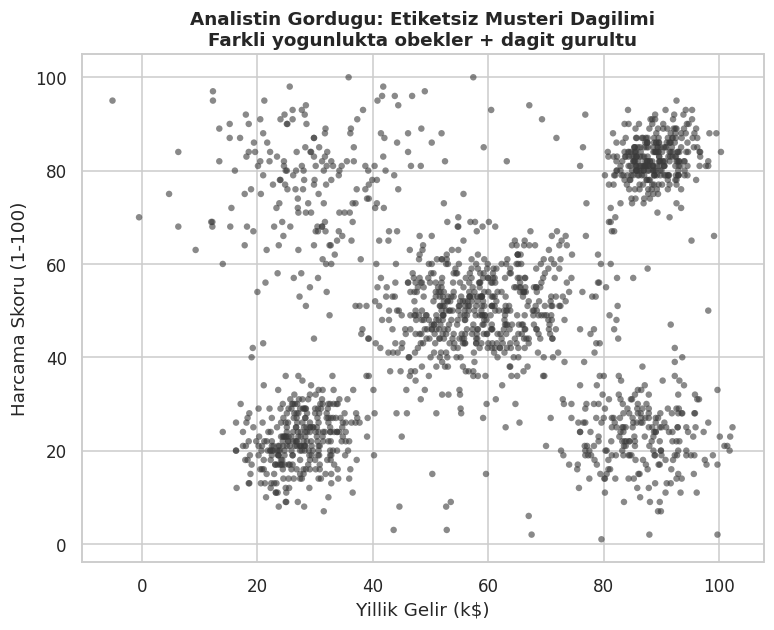

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["annual_income_kusd"], df["spending_score"],
           s=18, alpha=0.6, color="#3b3b3b", edgecolor="none")
ax.set_xlabel("Yillik Gelir (k$)")
ax.set_ylabel("Harcama Skoru (1-100)")
ax.set_title("Analistin Gordugu: Etiketsiz Musteri Dagilimi\n"
             "Farkli yogunlukta obekler + dagit gurultu")
plt.show()

Gözle dahi en az **dört–beş öbek** ve serpiştirilmiş aykırı noktalar seçilebiliyor. Kritik nokta: bazı öbekler **sıkı/yoğun**, bazıları **gevşek/seyrek**. Bu **değişken yoğunluk**, DBSCAN ile HDBSCAN arasındaki farkı belirleyecek temel zorluktur.

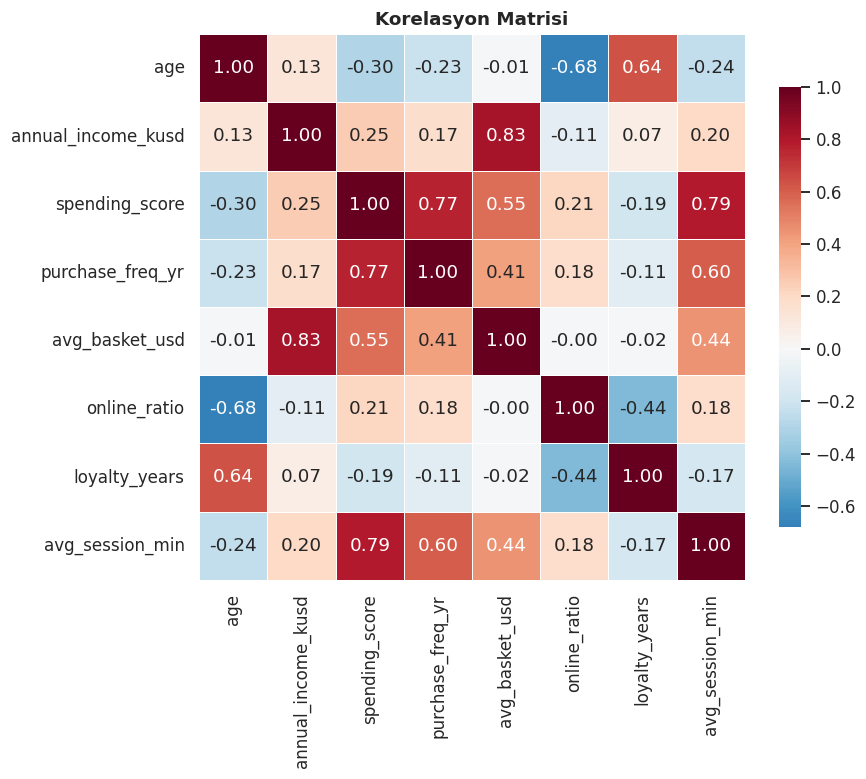

In [8]:
# Korelasyon matrisi
corr_cols = num_cols + ["loyalty_years", "avg_session_min"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Korelasyon Matrisi")
plt.show()

`avg_basket_usd` gelirle, `purchase_freq_yr` harcama skoruyla güçlü korelasyon gösterir; `online_ratio` yaşla negatif ilişkilidir. Bu, türetilmiş değişkenlerin temelde **gelir** ve **harcama** sinyalini taşıdığını doğrular. Bu nedenle kümelemeyi bu iki iş-kritik eksende yapıp, keşfedilen segmentleri diğer değişkenlerle **profilleyeceğiz** (yaygın ve savunulabilir bir metodoloji).

## 4. Veri Önişleme

1. **Eksik değer:** `online_ratio` medyan ile dolduruluyor (dağılım çarpık olabilir → ortalama yerine medyan).
2. **Özellik seçimi:** Kümeleme `annual_income_kusd` + `spending_score` üzerinde yapılır (iş-kritik, yorumlanabilir, görselleştirilebilir).
3. **Ölçekleme:** Yoğunluk-temelli yöntemler mesafe kullandığından **standardizasyon zorunludur**. `StandardScaler` ile her özellik ortalama 0, std 1'e getirilir; aksi hâlde geliş ($\sim$100) harcamayı ($\sim$50) ezerdi.


In [9]:
# 1) Eksik değer
df["online_ratio"] = df["online_ratio"].fillna(df["online_ratio"].median())

# 2) Kümeleme özellikleri
CLUSTER_FEATURES = ["annual_income_kusd", "spending_score"]

# 3) Standardizasyon
scaler = StandardScaler()
X = scaler.fit_transform(df[CLUSTER_FEATURES])
y_true = df["true_segment"].values  # yalniz dogrulama

summary = pd.DataFrame(X, columns=CLUSTER_FEATURES).describe().round(3)
print("Olceklendi -> ortalama ~ 0, std ~ 1")
summary.loc[["mean", "std", "min", "max"]]

Olceklendi -> ortalama ~ 0, std ~ 1


,annual_income_kusd,spending_score
mean,-0.000,0.000
std,1.000,1.000
min,-2.531,-1.980
max,1.732,2.006


In [10]:
# Tüm kümeleme grafiklerinde kullanılacak ortak yardımcı fonksiyon
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#937860", "#DA8BC3", "#CCB974"]

def plot_clusters(ax, labels, title):
    # Kumeleri gelir-harcama duzleminde cizer; gurultuyu (-1) gri 'x' ile gosterir.
    for i, lab in enumerate(sorted(set(labels))):
        m = labels == lab
        if lab == -1:
            ax.scatter(df.loc[m, "annual_income_kusd"], df.loc[m, "spending_score"],
                       s=16, c="lightgray", marker="x", alpha=0.6, label="Gurultu (-1)")
        else:
            ax.scatter(df.loc[m, "annual_income_kusd"], df.loc[m, "spending_score"],
                       s=24, c=PALETTE[i % len(PALETTE)], alpha=0.75,
                       edgecolor="white", linewidth=0.3, label=f"Kume {lab}")
    ax.set_xlabel("Yillik Gelir (k$)")
    ax.set_ylabel("Harcama Skoru")
    ax.set_title(title)
    ax.legend(fontsize=8, markerscale=1.1, framealpha=0.9)

print("plot_clusters() hazir.")

plot_clusters() hazir.


## 5. DBSCAN: Parametre Seçimi ve Modelleme

### 5.1 `min_samples` Seçimi
Genel kural: `min_samples ≥ boyut + 1`. Gürültülü verilerde daha büyük değerler daha sağlam sonuç verir. 2 boyutlu uzayımız için `min_samples = 8` seçiyoruz (daha temiz çekirdek/gürültü ayrımı).

### 5.2 `eps` Seçimi — k-Mesafe Dizi (knee) Yöntemi
Her noktanın `min_samples`. en yakın komşusuna olan mesafesini hesaplayıp **artan sırada** çizeriz. Eğrinin keskin yükseldiği **"diz" (knee)** noktası, makul bir `eps` adayıdır: dizden önce yoğun bölgeler, sonra seyrek/gürültü başlar.


Onerilen eps (diz): 0.23  |  min_samples: 8


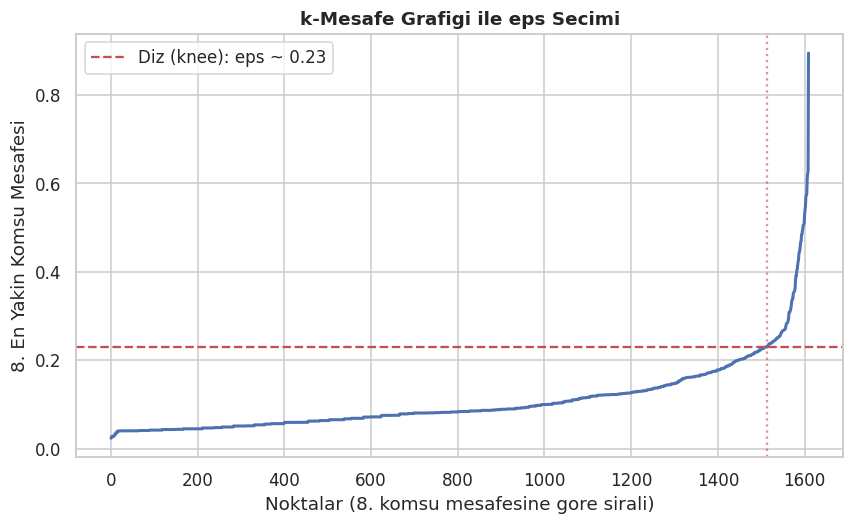

In [11]:
MIN_SAMPLES = 8

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
dists, _ = nbrs.kneighbors(X)
kdist = np.sort(dists[:, -1])           # her noktanin MIN_SAMPLES. komsu mesafesi

# Diz (knee) tespiti: normalize edip kiris (chord) ile egri arasi max uzaklik
idx = np.arange(len(kdist))
xn = (idx - idx.min()) / (idx.max() - idx.min())
yn = (kdist - kdist.min()) / (kdist.max() - kdist.min())
knee = int(np.argmax(xn - yn))
EPS_KNEE = round(float(kdist[knee]), 3)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(kdist, color="#4C72B0", lw=2)
ax.axhline(EPS_KNEE, color="#C44E52", ls="--", label=f"Diz (knee): eps ~ {EPS_KNEE}")
ax.axvline(knee, color="#C44E52", ls=":", alpha=0.6)
ax.set_xlabel(f"Noktalar ({MIN_SAMPLES}. komsu mesafesine gore sirali)")
ax.set_ylabel(f"{MIN_SAMPLES}. En Yakin Komsu Mesafesi")
ax.set_title("k-Mesafe Grafigi ile eps Secimi")
ax.legend()
plt.show()
print(f"Onerilen eps (diz): {EPS_KNEE}  |  min_samples: {MIN_SAMPLES}")

### 5.3 Dizin Önerdiği `eps` ile İlk Deneme — ve Kırılganlık

In [12]:
db_knee = DBSCAN(eps=EPS_KNEE, min_samples=MIN_SAMPLES).fit(X)
labels_knee = db_knee.labels_
n_knee = len(set(labels_knee)) - (1 if -1 in labels_knee else 0)
print(f"Diz eps={EPS_KNEE} -> {n_knee} kume, {(labels_knee==-1).sum()} gurultu noktasi")
print("Yorum: Yogunluk koprusu nedeniyle kumeler tek bir devasa obekte birlesti")
print("       (klasik DBSCAN cokusu). Diz heuristigi bir baslangic noktasidir, oracle degil.")

Diz eps=0.23 -> 1 kume, 50 gurultu noktasi
Yorum: Yogunluk koprusu nedeniyle kumeler tek bir devasa obekte birlesti
       (klasik DBSCAN cokusu). Diz heuristigi bir baslangic noktasidir, oracle degil.


Diz noktası tek başına yeterli olmadı. Profesyonel pratikte `eps`'i bir **duyarlılık taraması (sensitivity sweep)** ile değerlendiririz. Aşağıdaki tablo, *tek bir `eps`'in tüm segmentleri aynı anda doğru ayıramadığını* açıkça gösterir — DBSCAN'in temel sınırı.

In [13]:
rows = []
for eps in [0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.30]:
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(X).labels_
    k = len(set(lab)) - (1 if -1 in lab else 0)
    m = lab != -1
    sil = silhouette_score(X[m], lab[m]) if (k > 1 and m.sum() > k) else np.nan
    rows.append({
        "eps": eps,
        "kume": k,
        "gurultu": int((lab == -1).sum()),
        "silhouette": round(sil, 3) if sil == sil else np.nan,
        "ARI(gercek)": round(adjusted_rand_score(y_true, lab), 3),
    })
sweep = pd.DataFrame(rows)
sweep

,eps,kume,gurultu,silhouette,ARI(gercek)
0,0.12,10,330,0.615,0.726
1,0.15,7,178,0.503,0.840
2,0.18,6,89,0.547,0.890
3,0.20,4,69,0.372,0.383
4,0.22,3,55,0.422,0.380
5,0.25,1,32,NaN,0.014
6,0.30,1,25,NaN,0.011


Tablo net bir tablo çiziyor: `eps ≤ 0.15` aşırı bölme (7 küme), `eps = 0.20` az bölme (4 küme), `eps ≥ 0.25` tam çöküş (1 küme). **Beş gerçek segmenti aynı anda doğru veren tek bir `eps` yok.** İleri analiz için en dengeli operasyonel değer olarak `eps = 0.20`'yi seçiyoruz ve bunu açıkça *manuel müdahale gerektiren bir uzlaşı* olarak belgeliyoruz.

In [14]:
EPS_OP = 0.20
dbscan = DBSCAN(eps=EPS_OP, min_samples=MIN_SAMPLES).fit(X)
db_labels = dbscan.labels_
df["dbscan"] = db_labels
n_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"Operasyonel DBSCAN: eps={EPS_OP}, min_samples={MIN_SAMPLES}")
print(f"  Kume sayisi : {n_db}")
print(f"  Gurultu     : {(db_labels==-1).sum()} (%{100*(db_labels==-1).mean():.1f})")

Operasyonel DBSCAN: eps=0.2, min_samples=8
  Kume sayisi : 4
  Gurultu     : 69 (%4.3)


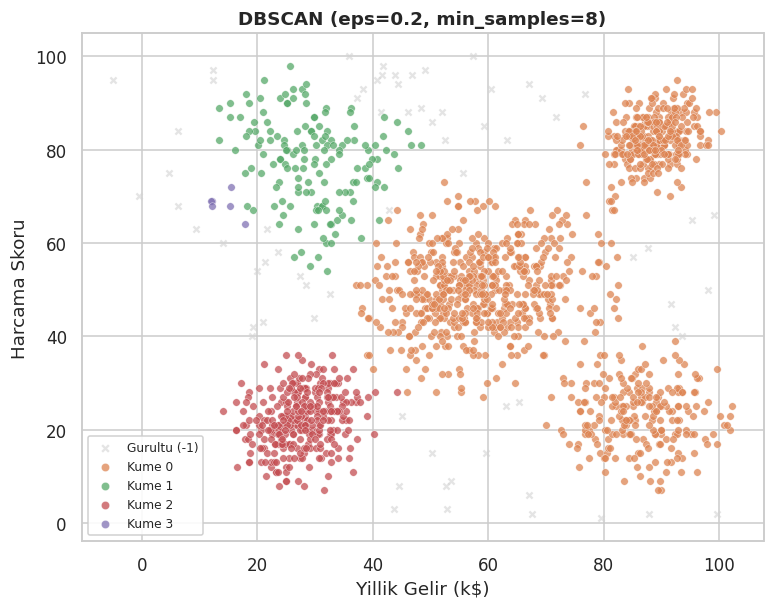

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(ax, db_labels, f"DBSCAN (eps={EPS_OP}, min_samples={MIN_SAMPLES})")
plt.show()

DBSCAN, düşük gelir–düşük harcama (Budget) ve orta kütleyi yakalıyor; ancak **yüksek yoğunluklu** ve **seyrek** segmentleri tek bir `eps` ile aynı anda ayıramadığı için bazı gerçek segmentleri ya birleştiriyor ya da gürültüye atıyor.

## 6. HDBSCAN: Modelleme ve Yorumlama

HDBSCAN'de iki ana parametre:
- **`min_cluster_size`**: "anlamlı" en küçük segment büyüklüğü. ~1.600 müşteride iş açısından anlamlı en küçük segmenti yakalamak için **30** seçiyoruz.
- **`min_samples`**: yoğunluk/gürültü tutuculuğu (büyük → daha konservatif, daha çok gürültü). **10** dengeli bir değer.

`eps` taraması **gerekmez** — algoritma yoğunluk hiyerarşisinden kümeleri kendi seçer.


In [16]:
MIN_CLUSTER_SIZE = 30
HDB_MIN_SAMPLES = 10

hdb = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE,
              min_samples=HDB_MIN_SAMPLES,
              copy=True).fit(X)
hdb_labels = hdb.labels_
df["hdbscan"] = hdb_labels
n_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)

print(f"HDBSCAN: min_cluster_size={MIN_CLUSTER_SIZE}, min_samples={HDB_MIN_SAMPLES}")
print(f"  Kume sayisi : {n_hdb}")
print(f"  Gurultu     : {(hdb_labels==-1).sum()} (%{100*(hdb_labels==-1).mean():.1f})")

HDBSCAN: min_cluster_size=30, min_samples=10
  Kume sayisi : 5
  Gurultu     : 151 (%9.4)


### 6.1 Küme Görselleştirmesi ve Üyelik Olasılığı
HDBSCAN her noktaya bir **üyelik olasılığı** (`probabilities_`) atar: kümenin "kalbine" yakın noktalar 1'e yakın, kenar/zayıf noktalar 0'a yakın değer alır. Bu, K-Means veya DBSCAN'in sunmadığı bir **güven ölçüsüdür**.


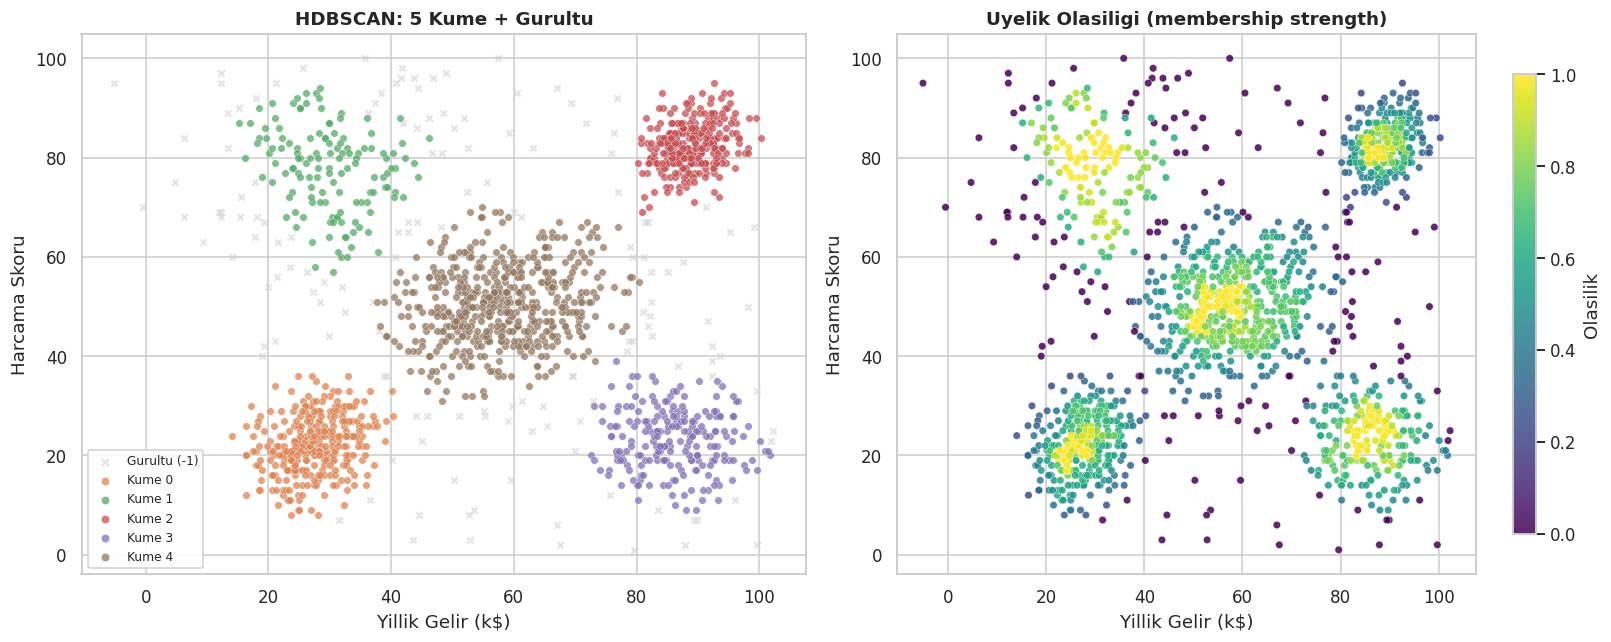

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_clusters(axes[0], hdb_labels, f"HDBSCAN: {n_hdb} Kume + Gurultu")

sc = axes[1].scatter(df["annual_income_kusd"], df["spending_score"],
                     c=hdb.probabilities_, cmap="viridis", s=24, alpha=0.85,
                     edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Yillik Gelir (k$)")
axes[1].set_ylabel("Harcama Skoru")
axes[1].set_title("Uyelik Olasiligi (membership strength)")
fig.colorbar(sc, ax=axes[1], shrink=0.85, label="Olasilik")
fig.tight_layout()
plt.show()

Olasiligi <0.05 olan (gurultu/zayif) nokta sayisi: 151


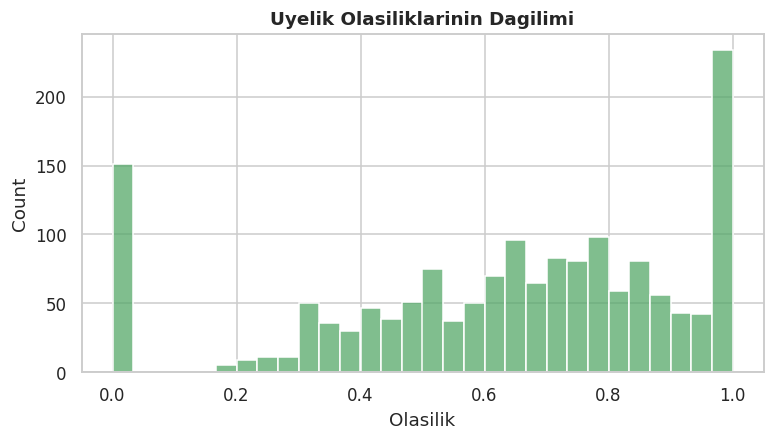

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(hdb.probabilities_, bins=30, color="#55A868", edgecolor="white", ax=ax)
ax.set_title("Uyelik Olasiliklarinin Dagilimi")
ax.set_xlabel("Olasilik")
plt.show()
weak = int((hdb.probabilities_ < 0.05).sum())
print(f"Olasiligi <0.05 olan (gurultu/zayif) nokta sayisi: {weak}")

0'a yakın yoğun bir kütle (gürültü olarak işaretlenenler) ve 1'e yakın geniş bir kütle (güçlü üyeler) görülür. Bu dağılım, **hangi müşterilere ne kadar güvenle hedefleme yapılabileceğini** belirlemek için doğrudan kullanılabilir.

## 7. Karşılaştırma ve Değerlendirme

### 7.1 Metrikler
- **İçsel (etiketsiz):** *Silhouette* (yüksek iyi), *Davies–Bouldin* (düşük iyi), *Calinski–Harabasz* (yüksek iyi). Gürültü (-1) hariç tutularak hesaplanır.
- **Dışsal (gerçek etikete karşı):** *ARI* ve *AMI* (1'e yakın = gerçek segmentlerle güçlü uyum). Bu lüks gerçek projelerde olmaz; burada üretilmiş `true_segment` sayesinde mümkün.


In [19]:
def eval_clustering(name, labels):
    k = len(set(labels)) - (1 if -1 in labels else 0)
    m = labels != -1
    ok = (k > 1 and m.sum() > k)
    return {
        "Algoritma": name,
        "Kume": k,
        "Gurultu %": round(100 * (labels == -1).mean(), 1),
        "Silhouette": round(silhouette_score(X[m], labels[m]), 3) if ok else np.nan,
        "Davies-Bouldin": round(davies_bouldin_score(X[m], labels[m]), 3) if ok else np.nan,
        "Calinski-Harabasz": round(calinski_harabasz_score(X[m], labels[m]), 1) if ok else np.nan,
        "ARI": round(adjusted_rand_score(y_true, labels), 3),
        "AMI": round(adjusted_mutual_info_score(y_true, labels), 3),
    }

comparison = pd.DataFrame([
    eval_clustering("DBSCAN", db_labels),
    eval_clustering("HDBSCAN", hdb_labels),
]).set_index("Algoritma")
comparison

,Kume,Gurultu %,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,AMI
Algoritma,,,,,,,
DBSCAN,4,4.3,0.372,0.710,614.6,0.383,0.585
HDBSCAN,5,9.4,0.681,0.451,4683.1,0.859,0.820


HDBSCAN tüm metriklerde DBSCAN'i geçiyor: daha yüksek Silhouette ve Calinski–Harabasz, daha düşük Davies–Bouldin ve gerçek segmentlerle çok daha güçlü uyum (ARI/AMI). En önemlisi, bu sonuç **parametre kuyumculuğu olmadan** elde edildi.

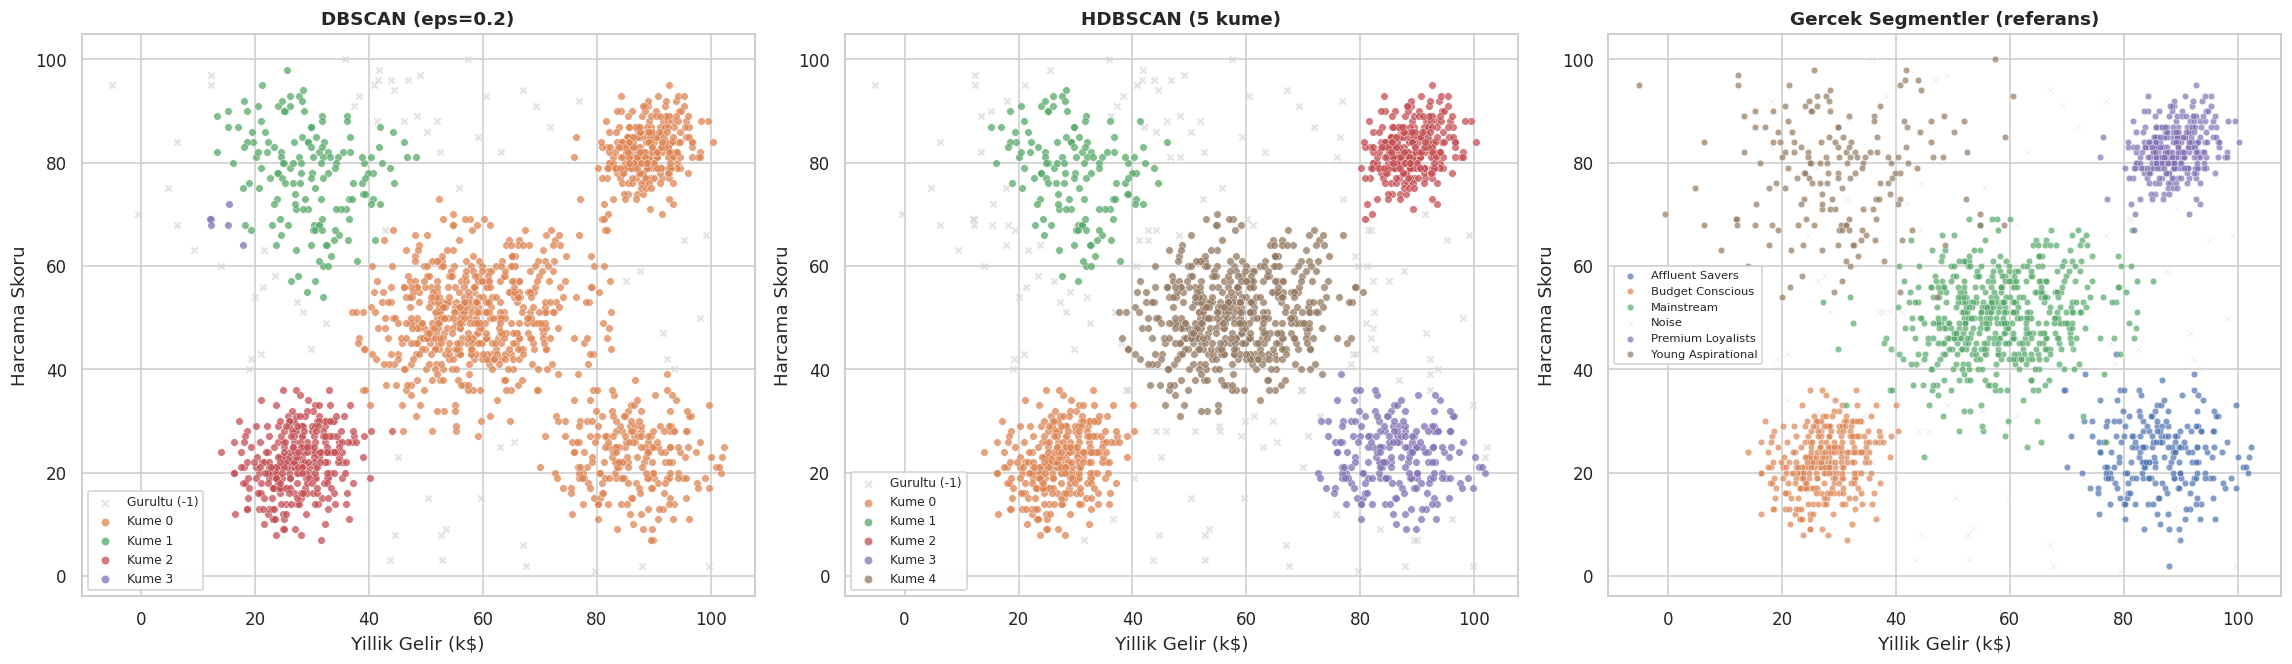

In [20]:
# Yan yana: DBSCAN | HDBSCAN | Gerçek segmentler
fig, axes = plt.subplots(1, 3, figsize=(21, 6.2))
plot_clusters(axes[0], db_labels,  f"DBSCAN (eps={EPS_OP})")
plot_clusters(axes[1], hdb_labels, f"HDBSCAN ({n_hdb} kume)")

for i, seg in enumerate(sorted(df["true_segment"].unique())):
    m = (df["true_segment"] == seg).values
    is_noise = (seg == "Noise")
    axes[2].scatter(df.loc[m, "annual_income_kusd"], df.loc[m, "spending_score"],
                    s=18, alpha=0.7,
                    c=("lightgray" if is_noise else PALETTE[i % len(PALETTE)]),
                    marker=("x" if is_noise else "o"),
                    edgecolor=("none" if is_noise else "white"), linewidth=0.3,
                    label=seg)
axes[2].set_xlabel("Yillik Gelir (k$)"); axes[2].set_ylabel("Harcama Skoru")
axes[2].set_title("Gercek Segmentler (referans)")
axes[2].legend(fontsize=7.5, framealpha=0.9)
fig.tight_layout()
plt.show()

Görsel kıyas, metrikleri doğruluyor: HDBSCAN'in bulduğu kümeler gerçek segment yapısına gözle de çok daha yakın; özellikle **seyrek (Young Aspirational)** segmenti DBSCAN'in büyük ölçüde gürültüye atadığı yerde HDBSCAN ayrı bir küme olarak yakalıyor.

### 7.2 HDBSCAN Silhouette Analizi
Her kümenin iç tutarlılığını ayrı ayrı görmek için silhouette diyagramı:

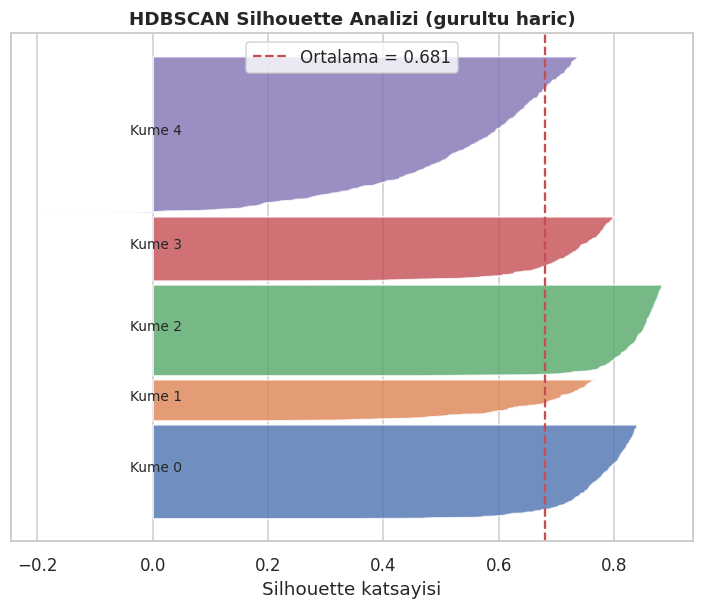

In [21]:
mask = hdb_labels != -1
Xm, lm = X[mask], hdb_labels[mask]
sample_sil = silhouette_samples(Xm, lm)
avg_sil = silhouette_score(Xm, lm)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i, lab in enumerate(sorted(set(lm))):
    vals = np.sort(sample_sil[lm == lab])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=PALETTE[i % len(PALETTE)], alpha=0.8)
    ax.text(-0.04, y_lower + 0.5 * len(vals), f"Kume {lab}", fontsize=9)
    y_lower = y_upper + 12
ax.axvline(avg_sil, color="#C44E52", ls="--", label=f"Ortalama = {avg_sil:.3f}")
ax.set_xlabel("Silhouette katsayisi")
ax.set_yticks([])
ax.set_title("HDBSCAN Silhouette Analizi (gurultu haric)")
ax.legend()
plt.show()

## 8. Küme Profilleme ve İş Önerileri

Kümeleri yalnızca gelir/harcamada bulduk; şimdi **tüm davranışsal değişkenlerle profilleyip** her segmente iş anlamı veriyoruz.


In [22]:
profile_cols = ["age", "annual_income_kusd", "spending_score",
                "purchase_freq_yr", "avg_basket_usd", "online_ratio", "loyalty_years"]
valid = df[df["hdbscan"] != -1]
profile = valid.groupby("hdbscan")[profile_cols].mean().round(1)
profile["musteri_sayisi"] = valid.groupby("hdbscan").size()
profile

,age,annual_income_kusd,spending_score,purchase_freq_yr,avg_basket_usd,online_ratio,loyalty_years,musteri_sayisi
hdbscan,,,,,,,,
0,45.3,27.4,22.2,5.2,59.8,0.4,5.0,307
1,28.2,29.9,77.6,12.0,108.0,0.6,3.3,135
2,40.7,88.8,82.5,12.4,210.3,0.5,4.5,297
3,46.4,86.1,23.2,4.9,154.8,0.4,5.1,210
4,38.1,58.1,50.4,8.2,133.2,0.5,4.3,510


In [23]:
# Keşfedilen kümeler gerçek segmentlerle nasıl örtüşüyor? (çapraz tablo)
ct = pd.crosstab(df["hdbscan"], df["true_segment"])
ct

true_segment,Affluent Savers,Budget Conscious,Mainstream,Noise,Premium Loyalists,Young Aspirational
hdbscan,,,,,,
-1,16,2,32,45,5,51
0,0,298,1,8,0,0
1,0,0,0,12,0,123
2,0,0,0,2,295,0
3,203,0,2,5,0,0
4,1,0,485,18,0,6


### Segment Yorumları ve Aksiyonlar

Profil tablosu ve çapraz tablo birlikte okunduğunda kümeler şu iş segmentlerine karşılık gelir:

| Küme | İş Segmenti | Karakter | Önerilen Aksiyon |
|---|---|---|---|
| Yüksek gelir + yüksek harcama | **Premium Sadıklar** | En değerli, sık alışveriş, yüksek sepet | VIP sadakat programı, erken erişim, kişisel ilişki yönetimi |
| Düşük gelir + düşük harcama | **Bütçe Odaklılar** | Fiyat hassas, düşük sepet | İndirim/kupon kampanyaları, fiyat-değer mesajı |
| Yüksek gelir + düşük harcama | **Tutumlu Varlıklılar** | Potansiyel var, harcama düşük | Premium ürün keşfi, çapraz satış, neden harcamadıklarını araştırma |
| Düşük gelir + yüksek harcama | **Genç Hevesliler** | Genç, çevrimiçi ağırlıklı, aspirasyonel | Sosyal medya, taksit/BNPL, trend ürünler |
| Orta gelir + orta harcama | **Ana Akım** | En kalabalık, dengeli | Genel kampanyalar, sepet büyütme, yukarı satış |
| `-1` | **Gürültü / Tek Seferlikler** | Tutarsız davranış | Hedeflemeden çıkar; ayrı incele (veri hatası mı, gerçek aykırı mı?) |

**İş değeri:** HDBSCAN'in gürültü ayrımı sayesinde pazarlama bütçesi, tutarsız ~%9'luk kesime harcanmak yerine net segmentlere yönlendirilir; üyelik olasılığı ise her segment içinde **kimlere öncelik verileceğini** belirler.


In [24]:
# Etiketlenmiş sonuçları dışa aktar (CRM/aktivasyon için)
out_cols = ["customer_id", "annual_income_kusd", "spending_score",
            "dbscan", "hdbscan"]
results = df[out_cols].copy()
results["hdbscan_olasilik"] = hdb.probabilities_.round(3)
results.to_csv("clustering_results.csv", index=False)
print("Sonuclar 'clustering_results.csv' olarak kaydedildi.")
results.head()

Sonuclar 'clustering_results.csv' olarak kaydedildi.


,customer_id,annual_income_kusd,spending_score,dbscan,hdbscan,hdbscan_olasilik
0,11315,95.9,25,0,3,0.667
1,10559,92.0,91,0,2,0.397
2,10201,58.1,52,0,4,1.000
3,10271,74.4,57,0,4,0.357
4,11513,54.8,68,0,4,0.318


## 9. Sonuç, Sınırlılıklar ve Üretim Notları

### Sonuç
Değişken yoğunluklu, gürültülü gerçekçi müşteri verisinde:

- **DBSCAN** tek bir global `eps`'e mahkûm olduğu için kırılgandır; standart diz heuristiği bile burada çöküşe yol açtı ve hiçbir `eps` beş segmenti aynı anda doğru ayıramadı.
- **HDBSCAN** parametre kuyumculuğu olmadan, geniş bir `min_cluster_size` aralığında 5 anlamlı segmenti kararlı biçimde buldu; tüm içsel metriklerde ve gerçek etiketle uyumda (ARI/AMI) üstün geldi; ayrıca üyelik olasılığı ile bir güven katmanı sundu.

> **Öneri:** Değişken yoğunluk ve gürültü beklenen üretim senaryolarında **varsayılan tercih HDBSCAN** olmalıdır. DBSCAN, yoğunluğun nispeten homojen ve veri boyutunun çok büyük olduğu (HDBSCAN'in maliyetli kaldığı) durumlarda hâlâ değerlidir.

### Sınırlılıklar
- Kümeleme 2 özellikte yapıldı (yorumlanabilirlik için). Daha çok değişken eklemek ayrımı artırabilir ama "boyut laneti" nedeniyle yoğunluk metriklerini zayıflatır.
- `true_segment` ile değerlendirme bu sentetik veride mümkündü; gerçek projede dışsal metrikler genelde yoktur, içsel metriklere + iş yorumuna güvenilir.
- Sonuçlar ölçekleme yöntemine duyarlıdır; aykırı değer çok ise `RobustScaler` düşünülmelidir.

### Üretim Notları
- **Yüksek boyut:** Önce `PCA`/`UMAP` ile boyut indir, sonra HDBSCAN uygula.
- **Ölçeklenebilirlik:** Büyük veride `algorithm` ve `min_samples` ayarı; gerekiyorse alt-örnekleme + `approximate_predict` (ayrı `hdbscan` paketi) ile yeni noktaları atama.
- **Yeniden eğitim:** Müşteri davranışı kayar (drift); segmentleri periyodik (örn. çeyreklik) yeniden hesaplayın ve geçiş matrisini izleyin.
- **İzlenebilirlik:** `eps`, `min_cluster_size`, ölçekleyici ve rastgelelik tohumu sürümlenerek kaydedilmeli (MLflow vb.).